### micrograd(自动微分模块)
#### https://github.com/karpathy/micrograd


In [1]:
import math
import numpy as np 
import matplotlib.pyplot as plt 
import random

In [2]:
# Value类
class Value:
    def __init__(self,data,_children=(),_op='',label=""):
        self.data = data
        self._prev = set(_children)
        self.grad = 0.0
        self._backward = lambda: None
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
    # 加法
    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data,(self,other),"+")
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out
    def __radd__(self, other):
        return self + other
    # 乘法
    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data,(self,other),"*")

        def _backward():
            self.grad +=  other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    def __rmul__(self, other):
        return self * other
    # tanh
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1) / (math.exp(2*x)+1)
        out = Value(t,(self, ),'tanh')

        def _backward():
            self.grad +=  (1-t**2) * out.grad
        out._backward = _backward

        return out
    # e^x
    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self, ),'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
    # x**y
    def __pow__(self, other):
        assert isinstance(other,(int,float)),"only supporting int/float powers for now"
        out = Value(self.data**other,(self,),f'**{other}')
        def _backward():
            self.grad += other * (self.data ** (other-1)) * out.grad
        out._backward = _backward

        return out

    # 除法
    def __truediv__(self, other):
        return self * other**-1
    # 减法
    def __sub__(self, other):
        return self + (-other)
    # 相反数
    def __neg__(self):
        return self * -1
    # backward
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

In [3]:
# 为了绘图展示的部分
from graphviz import Digraph

def trace(root):
    nodes,edges = set(),set()
    def build(v):
        if v in nodes:
            return
        nodes.add(v)
        for child in v._prev:
            edges.add((child,v))
            build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot = Digraph(format='svg',graph_attr={'rankdir':'LR'})

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid,label="{%s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad),shape='record')
        if n._op:
            dot.node(name=uid+n._op,label=n._op)
            dot.edge(uid+n._op,uid)
    
    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2)) + n2._op)
    
    return dot

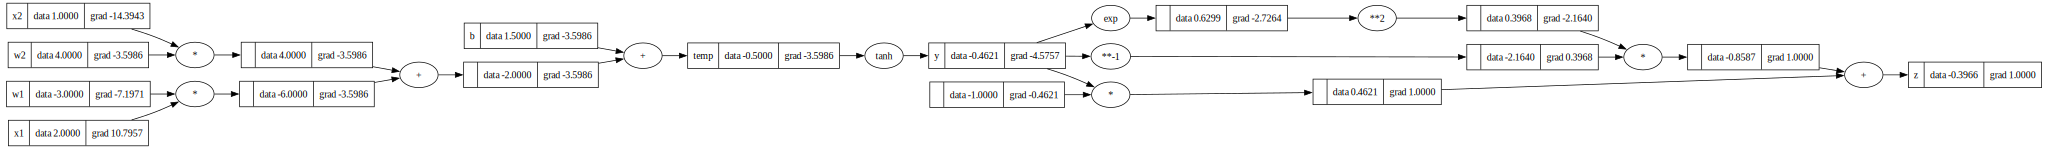

In [4]:
# 定义变量
x1 = Value(2.0, label='x1')
x2 = Value(1.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(4.0, label='w2')
b = Value(1.5, label='b')

# 🔥 超级复杂表达式（所有运算符都用到了）
# 乘法 + 加法 + 除法 + 幂次 + exp + tanh + 减法 + 负数
temp = x1*w1 + x2*w2 + b       # 乘、加
temp.label = 'temp'

y = temp.tanh()                # tanh
y.label = 'y'

z = y.exp() ** 2 / y - y       # exp、幂、除、减
z.label = 'z'

# 反向传播
z.backward()
# 画图
dot = draw_dot(z)
dot
# dot.render("output", view=True)  # 自动保存并打开图片

In [5]:
# 简易神经网络
# 单个神经元
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
                       
    def __call__(self, x):
        # 前向传播：w·x + b，再通过 tanh 激活
        # 计算加权和：sum(wi * xi) + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        # 激活函数：tanh
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
# 一层神经元
class Layer:
    def __init__(self, nin, nout):
        # nin: 输入特征数（该层每个神经元的输入维度）
        # nout: 该层的神经元数量（输出维度）
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        # 前向传播：所有神经元分别计算输出，组成列表
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
# 多层感知机
class MLP:
    def __init__(self, nin, nouts):
        # nin: 输入层维度
        # nouts: 列表，定义每一层的输出维度（不包含输入层）
        # 例如 nouts = [4, 4, 1] 表示：
        # 输入层(3) → 隐藏层1(4) → 隐藏层2(4) → 输出层(1)
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        # 前向传播：逐层计算
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [15]:
x = [2.0, 3.0, -1.0]       # 输入向量（3维）
n = MLP(3, [4, 4, 1])      # 定义 MLP：3输入 → 4 → 4 → 1输出
n(x)                        # 前向传播
len(n.parameters())

41

In [24]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],
]
ys = [1.0,-1.0,-1.0,1.0]
for k in range (20):
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt,yout in zip(ys,ypred))
    
    for p in n.parameters():
        p.grad = 0.0
    
    loss.backward()
    
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k,loss.data)

0 0.003154026387159974
1 0.0031324747975036205
2 0.0031112086214025595
3 0.0030902223021329394
4 0.003069510425009446
5 0.0030490677129045357
6 0.0030288890219352807
7 0.0030089693373108505
8 0.002989303769333449
9 0.0029698875495463616
10 0.00295071602702289
11 0.0029317846647899173
12 0.002913089036380898
13 0.002894624822512461
14 0.0028763878078797533
15 0.00285837387806559
16 0.0028405790165585776
17 0.002822999301875963
18 0.0028056309047869493
19 0.0027884700856321406
